# 07-2. KMeans 비지도학습

7장에서는 데이터를 모델에 넣기 전에 살펴보고 정리하는 법을 배웠다.

이번 노트북에서는 정답 `y`가 없을 때 데이터를 비슷한 그룹으로 묶어본다.

KMeans는 딥러닝 모델은 아니지만, 데이터를 이해하기 위한 좋은 탐색 도구다.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 실습 결과가 매번 달라지지 않도록 난수 생성기를 고정한다.
rng = np.random.default_rng(42)


## 예제 데이터 만들기

원본 예제에는 `KMeansData.csv`가 있었지만, 이 교재에서는 파일이 없어도 바로 실행되도록 작은 데이터를 직접 만든다.

데이터는 두 개의 특성을 가진다고 생각하자.

```text
hours: 공부 시간처럼 생각할 수 있는 값
score: 시험 점수처럼 생각할 수 있는 값
```

우리는 일부러 세 덩어리처럼 보이는 데이터를 만든다.
하지만 모델에게 정답 그룹 번호는 주지 않는다.


In [2]:

# 세 그룹처럼 보이는 데이터를 만든다.
# loc는 그룹의 중심 위치, scale은 퍼져 있는 정도라고 생각하면 된다.
group_a = rng.normal(loc=[20, 80], scale=[5, 8], size=(60, 2))
group_b = rng.normal(loc=[70, 30], scale=[8, 6], size=(60, 2))
group_c = rng.normal(loc=[75, 85], scale=[6, 5], size=(60, 2))

# 세 그룹을 하나의 데이터로 합친다.
X = np.vstack([group_a, group_b, group_c])
df = pd.DataFrame(X, columns=["hours", "score"])

df.head()


,hours,score
0,21.523585,71.680127
1,23.752256,87.524518
2,10.244824,69.582564
3,20.639202,77.470059
4,19.915994,73.175649


In [3]:

# 7장에서 배운 기본 EDA를 먼저 한다.
print("데이터 모양:", df.shape)
print("\n기초 통계:")
display(df.describe())


데이터 모양: (180, 2)

기초 통계:


,hours,score
count,180.000000,180.000000
mean,55.104950,64.698866
std,25.996372,25.227852
min,10.244824,21.739883
25%,22.975309,33.566833
50%,67.156558,77.595001
75%,75.227252,84.671370
max,92.430403,95.465842


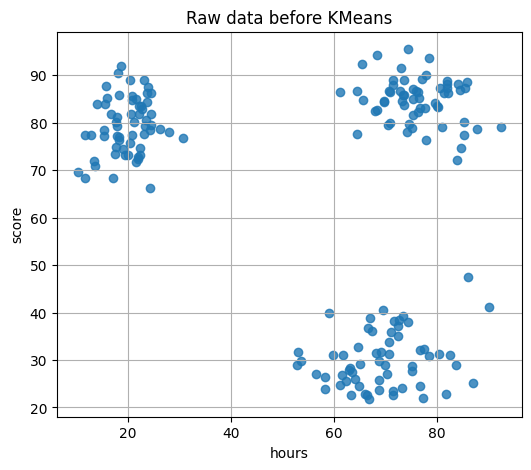

In [4]:

# 산점도로 데이터를 직접 확인한다.
# 아직 KMeans를 돌리지 않았다. 그냥 원본 데이터가 어떻게 생겼는지 보는 단계다.
plt.figure(figsize=(6, 5))
plt.scatter(df["hours"], df["score"], alpha=0.8)
plt.title("Raw data before KMeans")
plt.xlabel("hours")
plt.ylabel("score")
plt.grid(True)
plt.show()


## 표준화하기

KMeans는 거리 기반 방법이다.
숫자 범위가 큰 특성이 거리 계산을 지배할 수 있으므로, 먼저 표준화한다.

7장에서 배운 `StandardScaler`가 여기서 다시 등장한다.


In [5]:

scaler = StandardScaler()

# fit_transform은 두 일을 한 번에 한다.
# fit: 평균과 표준편차를 데이터에서 계산한다.
# transform: 계산한 평균과 표준편차를 사용해 값을 표준화한다.
X_scaled = scaler.fit_transform(df[["hours", "score"]])

scaled_df = pd.DataFrame(X_scaled, columns=["hours_scaled", "score_scaled"])
scaled_df.head()


,hours_scaled,score_scaled
0,-1.295374,0.277500
1,-1.209405,0.907304
2,-1.730444,0.194124
3,-1.329489,0.507646
4,-1.357386,0.336946


## Elbow Method로 K 후보 보기

KMeans는 몇 개 그룹으로 나눌지 `K`를 정해야 한다.

처음부터 K를 확신하기 어렵다면, 여러 K를 넣어보고 `inertia`가 어떻게 줄어드는지 본다.


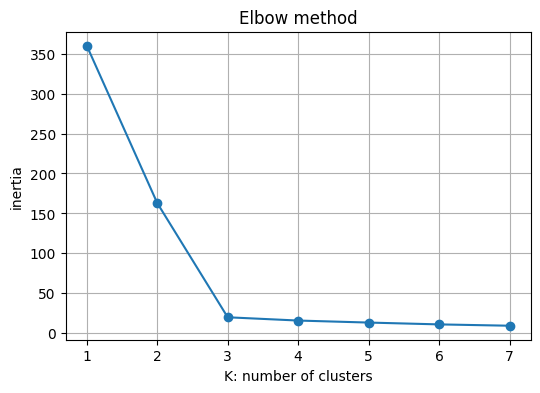

In [6]:

inertia_list = []
k_values = range(1, 8)

for k in k_values:
    # n_clusters는 나눌 그룹 수다.
    # n_init은 서로 다른 초기 중심점으로 몇 번 시도할지 정하는 옵션이다.
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_list.append(kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(k_values), inertia_list, marker="o")
plt.title("Elbow method")
plt.xlabel("K: number of clusters")
plt.ylabel("inertia")
plt.grid(True)
plt.show()


## KMeans 실행하기

이 예제 데이터는 눈으로 봤을 때 세 덩어리처럼 보인다.
그래서 먼저 `K = 3`으로 실행한다.


In [7]:

K = 3

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)

# fit_predict는 두 일을 한 번에 한다.
# fit: 중심점을 찾는다.
# predict: 각 데이터가 몇 번 군집에 속하는지 반환한다.
cluster_labels = kmeans.fit_predict(X_scaled)

df["cluster"] = cluster_labels
df.head()


,hours,score,cluster
0,21.523585,71.680127,2
1,23.752256,87.524518,2
2,10.244824,69.582564,2
3,20.639202,77.470059,2
4,19.915994,73.175649,2


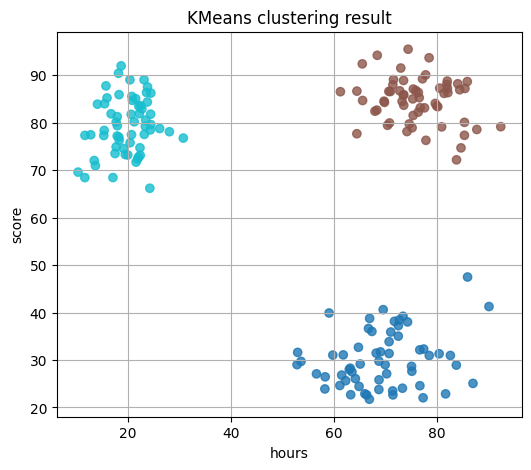

In [8]:

# KMeans가 찾은 군집 결과를 색으로 표시한다.
plt.figure(figsize=(6, 5))
plt.scatter(df["hours"], df["score"], c=df["cluster"], cmap="tab10", alpha=0.8)
plt.title("KMeans clustering result")
plt.xlabel("hours")
plt.ylabel("score")
plt.grid(True)
plt.show()


In [9]:

# 표준화된 공간에서 중심점을 확인한다.
centers_scaled = kmeans.cluster_centers_

# 사람이 원래 단위로 이해하기 쉽도록 중심점을 다시 원래 스케일로 되돌린다.
centers_original = scaler.inverse_transform(centers_scaled)
centers_df = pd.DataFrame(centers_original, columns=["center_hours", "center_score"])
centers_df


,center_hours,center_score
0,69.299610,30.121900
1,76.177056,84.682219
2,19.838182,79.292478


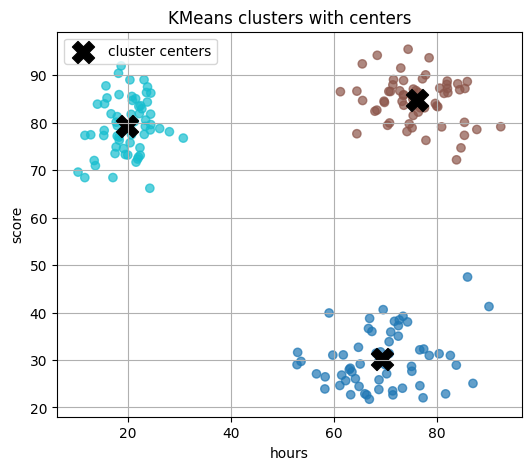

In [10]:

# 원본 데이터와 중심점을 함께 그린다.
plt.figure(figsize=(6, 5))
plt.scatter(df["hours"], df["score"], c=df["cluster"], cmap="tab10", alpha=0.7)
plt.scatter(
    centers_df["center_hours"],
    centers_df["center_score"],
    s=250,
    marker="X",
    c="black",
    label="cluster centers",
)
plt.title("KMeans clusters with centers")
plt.xlabel("hours")
plt.ylabel("score")
plt.legend()
plt.grid(True)
plt.show()


## 정리

이번 노트북에서 한 일은 다음과 같다.

```text
1. 정답 y가 없는 데이터를 준비했다.
2. 산점도로 데이터 모양을 확인했다.
3. StandardScaler로 표준화했다.
4. Elbow Method로 K 후보를 보았다.
5. KMeans로 데이터를 군집화했다.
6. 중심점을 원래 단위로 되돌려 해석했다.
```

KMeans는 딥러닝은 아니지만, 모델을 만들기 전 데이터를 이해하는 EDA 도구로 쓸 수 있다.
